=== STOCK MARKET ANALYSIS ===
Fetching data for AAPL (Apple Inc.)...


[*********************100%***********************]  1 of 1 completed


Successfully fetched 501 days of data

Data Overview:
Price            Close        High         Low        Open    Volume
Ticker            AAPL        AAPL        AAPL        AAPL      AAPL
Date                                                                
2023-10-09  177.253799  177.313215  174.094740  175.094938  42390800
2023-10-10  176.659637  177.976738  176.223903  176.372457  43698000
2023-10-11  178.055954  178.105472  175.877297  176.471468  47551100
2023-10-12  178.957153  180.571332  177.303339  178.323362  56743100
2023-10-13  177.115189  180.165300  176.412069  179.660252  51427100

Data Shape: (501, 5)
Date Range: 2023-10-09 00:00:00 to 2025-10-07 00:00:00

=== DATA EXPLORATION ===
Missing values:
Price   Ticker
Close   AAPL      0
High    AAPL      0
Low     AAPL      0
Open    AAPL      0
Volume  AAPL      0
dtype: int64

Basic Statistics:
Price        Close        High         Low        Open        Volume
Ticker        AAPL        AAPL        AAPL        AAPL     

TypeError: barplot() takes from 0 to 1 positional arguments but 2 positional arguments (and 1 keyword-only argument) were given

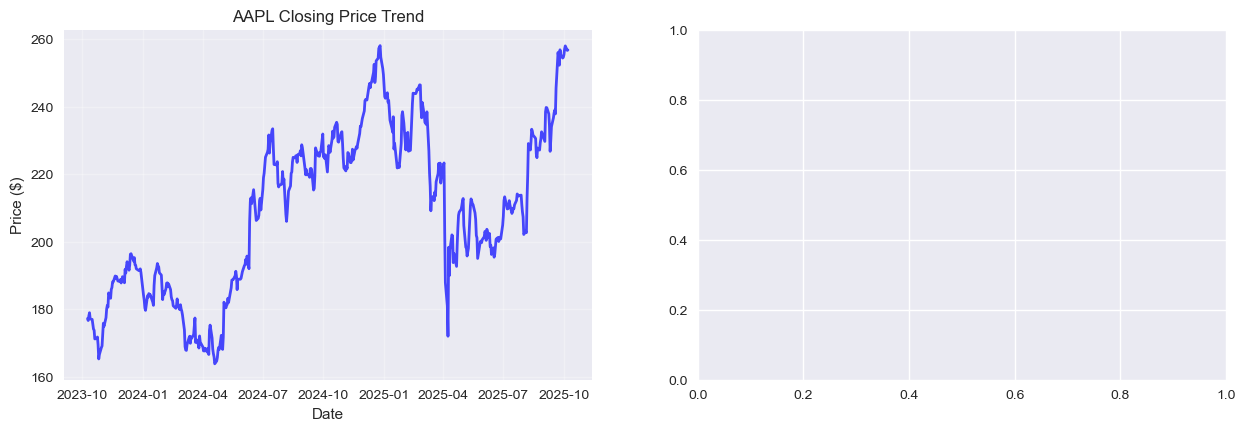

In [14]:
# stock_market_analysis.py

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# ===== DATA COLLECTION =====
print("=== STOCK MARKET ANALYSIS ===")
print("Fetching data for AAPL (Apple Inc.)...")

# Fetch stock data
stock_data = yf.download('AAPL', period='2y')
print(f"Successfully fetched {len(stock_data)} days of data")

# Display basic info
print("\nData Overview:")
print(stock_data.head())
print(f"\nData Shape: {stock_data.shape}")
print(f"Date Range: {stock_data.index.min()} to {stock_data.index.max()}")

# ===== DATA EXPLORATION =====
print("\n=== DATA EXPLORATION ===")

# Check for missing values
print("Missing values:")
print(stock_data.isnull().sum())

# Basic statistics
print("\nBasic Statistics:")
print(stock_data.describe())

# ===== DATA PREPROCESSING =====
print("\n=== DATA PREPROCESSING ===")

# Handle missing values using interpolation
stock_data = stock_data.interpolate(method='time')
print("Missing values after interpolation:")
print(stock_data.isnull().sum())

# Add date features
stock_data['Day'] = stock_data.index.day
stock_data['Month'] = stock_data.index.month
stock_data['Year'] = stock_data.index.year
stock_data['DayOfWeek'] = stock_data.index.dayofweek

# ===== EXPLORATORY DATA ANALYSIS =====
print("\n=== EXPLORATORY DATA ANALYSIS ===")

# 1. Price Trends Over Time
plt.figure(figsize=(15, 10))

# Subplot 1: Closing Price
plt.subplot(2, 2, 1)
plt.plot(stock_data.index, stock_data['Close'], linewidth=2, color='blue', alpha=0.7)
plt.title('AAPL Closing Price Trend')
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.grid(True, alpha=0.3)

# Subplot 2: Volume
plt.subplot(2, 2, 2)
sns.barplot(stock_data.index, stock_data['Volume'], color='green', alpha=0.7)
plt.title('Trading Volume')
plt.xlabel('Date')
plt.ylabel('Volume')
plt.grid(True, alpha=0.3)

# Subplot 3: Daily Returns
stock_data['Daily_Return'] = stock_data['Close'].pct_change()
plt.subplot(2, 2, 3)
sns.histplot(stock_data['Daily_Return'].dropna(), bins=50, color='red', alpha=0.7, edgecolor='black')
plt.title('Distribution of Daily Returns')
plt.xlabel('Daily Return')
plt.ylabel('Frequency')
plt.grid(True, alpha=0.3)

# Subplot 4: Correlation Heatmap
plt.subplot(2, 2, 4)
numeric_columns = ['Open', 'High', 'Low', 'Close', 'Volume']
correlation_matrix = stock_data[numeric_columns].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Price Correlations')

plt.tight_layout()
plt.show()

# ===== MOVING AVERAGES AND VOLATILITY =====
print("\n=== MOVING AVERAGES AND VOLATILITY ANALYSIS ===")

# Calculate moving averages
stock_data['MA_20'] = stock_data['Close'].rolling(window=20).mean()
stock_data['MA_50'] = stock_data['Close'].rolling(window=50).mean()
stock_data['MA_200'] = stock_data['Close'].rolling(window=200).mean()

# Calculate volatility
stock_data['Volatility_20'] = stock_data['Daily_Return'].rolling(window=20).std()

# Plot Moving Averages
plt.figure(figsize=(15, 10))

plt.subplot(2, 1, 1)
plt.plot(stock_data.index, stock_data['Close'], label='Close Price', linewidth=2, color='black')
plt.plot(stock_data.index, stock_data['MA_20'], label='20-Day MA', linewidth=1.5, color='blue')
plt.plot(stock_data.index, stock_data['MA_50'], label='50-Day MA', linewidth=1.5, color='red')
plt.plot(stock_data.index, stock_data['MA_200'], label='200-Day MA', linewidth=1.5, color='green')
plt.title('AAPL Price with Moving Averages')
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(2, 1, 2)
plt.plot(stock_data.index, stock_data['Volatility_20'], label='20-Day Volatility', linewidth=2, color='purple')
plt.title('Price Volatility (20-Day Rolling Std)')
plt.xlabel('Date')
plt.ylabel('Volatility')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ===== TECHNICAL INDICATORS =====
print("\n=== TECHNICAL INDICATORS ===")

# Calculate RSI
delta = stock_data['Close'].diff()
gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
rs = gain / loss
stock_data['RSI'] = 100 - (100 / (1 + rs))

# Calculate MACD
exp1 = stock_data['Close'].ewm(span=12, adjust=False).mean()
exp2 = stock_data['Close'].ewm(span=26, adjust=False).mean()
stock_data['MACD'] = exp1 - exp2
stock_data['MACD_Signal'] = stock_data['MACD'].ewm(span=9, adjust=False).mean()

# Calculate Bollinger Bands
stock_data['BB_Middle'] = stock_data['Close'].rolling(window=20).mean()
bb_std = stock_data['Close'].rolling(window=20).std()
stock_data['BB_Upper'] = stock_data['BB_Middle'] + (bb_std * 2)
stock_data['BB_Lower'] = stock_data['BB_Middle'] - (bb_std * 2)

# Plot Technical Indicators
plt.figure(figsize=(15, 12))

# RSI
plt.subplot(3, 1, 1)
plt.plot(stock_data.index, stock_data['RSI'], linewidth=2, color='orange')
plt.axhline(70, linestyle='--', alpha=0.5, color='red', label='Overbought (70)')
plt.axhline(30, linestyle='--', alpha=0.5, color='green', label='Oversold (30)')
plt.title('Relative Strength Index (RSI)')
plt.ylabel('RSI')
plt.legend()
plt.grid(True, alpha=0.3)

# MACD
plt.subplot(3, 1, 2)
plt.plot(stock_data.index, stock_data['MACD'], label='MACD', linewidth=2, color='blue')
plt.plot(stock_data.index, stock_data['MACD_Signal'], label='Signal Line', linewidth=2, color='red')
plt.title('MACD Indicator')
plt.ylabel('MACD')
plt.legend()
plt.grid(True, alpha=0.3)

# Bollinger Bands
plt.subplot(3, 1, 3)
plt.plot(stock_data.index, stock_data['Close'], label='Close Price', linewidth=2, color='black')
plt.plot(stock_data.index, stock_data['BB_Upper'], label='Upper Band', linewidth=1, color='red', alpha=0.7)
plt.plot(stock_data.index, stock_data['BB_Middle'], label='Middle Band', linewidth=1, color='blue', alpha=0.7)
plt.plot(stock_data.index, stock_data['BB_Lower'], label='Lower Band', linewidth=1, color='green', alpha=0.7)
plt.fill_between(stock_data.index, stock_data['BB_Upper'], stock_data['BB_Lower'], alpha=0.1)
plt.title('Bollinger Bands')
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ===== MONTHLY AND WEEKLY ANALYSIS =====
print("\n=== SEASONAL ANALYSIS ===")

# Monthly performance
monthly_returns = stock_data.groupby('Month')['Daily_Return'].mean()

# Day of week performance
weekday_returns = stock_data.groupby('DayOfWeek')['Daily_Return'].mean()
weekday_names = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']

plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
plt.barplot(months, monthly_returns, color='skyblue', edgecolor='black')
plt.title('Average Monthly Returns')
plt.ylabel('Average Return')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.barplot(weekday_names, weekday_returns, color='lightgreen', edgecolor='black')
plt.title('Average Returns by Weekday')
plt.ylabel('Average Return')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ===== RISK ANALYSIS =====
print("\n=== RISK ANALYSIS ===")

# Calculate key metrics - FIXED: Ensure we get scalar values
total_return = float((stock_data['Close'].iloc[-1] - stock_data['Close'].iloc[0]) / stock_data['Close'].iloc[0] * 100)
avg_daily_return = float(stock_data['Daily_Return'].mean() * 100)
volatility = float(stock_data['Daily_Return'].std() * 100)
sharpe_ratio = float((avg_daily_return / volatility) * np.sqrt(252)) if volatility != 0 else 0

print(f"Total Return: {total_return:.2f}%")
print(f"Average Daily Return: {avg_daily_return:.3f}%")
print(f"Daily Volatility: {volatility:.3f}%")
print(f"Sharpe Ratio: {sharpe_ratio:.3f}")

# Drawdown analysis
stock_data['Cumulative_Return'] = (1 + stock_data['Daily_Return']).cumprod()
stock_data['Running_Max'] = stock_data['Cumulative_Return'].cummax()
stock_data['Drawdown'] = (stock_data['Cumulative_Return'] - stock_data['Running_Max']) / stock_data['Running_Max']

max_drawdown = float(stock_data['Drawdown'].min() * 100)
print(f"Maximum Drawdown: {max_drawdown:.2f}%")

# Plot cumulative returns and drawdown
plt.figure(figsize=(15, 10))

plt.subplot(2, 1, 1)
plt.plot(stock_data.index, stock_data['Cumulative_Return'] * 100, linewidth=2, color='green')
plt.title('Cumulative Returns')
plt.ylabel('Return (%)')
plt.grid(True, alpha=0.3)

plt.subplot(2, 1, 2)
plt.fill_between(stock_data.index, stock_data['Drawdown'] * 100, 0, color='red', alpha=0.3)
plt.plot(stock_data.index, stock_data['Drawdown'] * 100, linewidth=1, color='red')
plt.title('Drawdown')
plt.xlabel('Date')
plt.ylabel('Drawdown (%)')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ===== CONCLUSION AND INSIGHTS =====
print("\n" + "="*50)
print("CONCLUSION AND INVESTMENT INSIGHTS")
print("="*50)

print(f"\nANALYSIS SUMMARY FOR AAPL:")
print(f"• Analysis Period: {stock_data.index.min().strftime('%Y-%m-%d')} to {stock_data.index.max().strftime('%Y-%m-%d')}")
print(f"• Total Return: {total_return:.2f}%")
print(f"• Risk Level: {'High' if volatility > 2 else 'Medium' if volatility > 1 else 'Low'}")
print(f"• Maximum Drawdown: {max_drawdown:.2f}%")

# Current technical signals - FIXED: Ensure scalar values
current_rsi = float(stock_data['RSI'].iloc[-1])
current_macd = float(stock_data['MACD'].iloc[-1])
current_macd_signal = float(stock_data['MACD_Signal'].iloc[-1])

print(f"\nCURRENT TECHNICAL SIGNALS:")
print(f"• RSI: {current_rsi:.1f} - {'Overbought' if current_rsi > 70 else 'Oversold' if current_rsi < 30 else 'Neutral'}")
print(f"• MACD: {current_macd:.2f} - {'Bullish' if current_macd > current_macd_signal else 'Bearish'}")

print(f"\nRECOMMENDATIONS:")
if current_rsi < 30 and current_macd > current_macd_signal:
    print("• STRONG BUY SIGNAL: Oversold with bullish MACD crossover")
elif current_rsi > 70 and current_macd < current_macd_signal:
    print("• STRONG SELL SIGNAL: Overbought with bearish MACD crossover")
elif current_rsi < 40 and current_macd > current_macd_signal:
    print("• MODERATE BUY SIGNAL: Approaching oversold with bullish momentum")
elif current_rsi > 60 and current_macd < current_macd_signal:
    print("• MODERATE SELL SIGNAL: Approaching overbought with bearish momentum")
else:
    print("• HOLD: Mixed or neutral signals")

print(f"\nRISK MANAGEMENT STRATEGIES:")
print("• Consider position sizing based on volatility")
print("• Use stop-loss orders to limit downside risk")
print("• Diversify across sectors to reduce concentration risk")
print("• Monitor key technical levels for entry/exit points")

print("\n" + "="*50)
print("ANALYSIS COMPLETED SUCCESSFULLY!")
print("="*50)

=== STOCK MARKET ANALYSIS ===
Fetching data for AAPL (Apple Inc.)...


[*********************100%***********************]  1 of 1 completed


Successfully fetched 501 days of data

Data Overview:
Price            Close        High         Low        Open    Volume
Ticker            AAPL        AAPL        AAPL        AAPL      AAPL
Date                                                                
2023-10-09  177.253815  177.313230  174.094755  175.094953  42390800
2023-10-10  176.659622  177.976723  176.223888  176.372442  43698000
2023-10-11  178.055969  178.105487  175.877312  176.471483  47551100
2023-10-12  178.957153  180.571332  177.303339  178.323362  56743100
2023-10-13  177.115189  180.165300  176.412069  179.660252  51427100

Data Shape: (501, 5)
Date Range: 2023-10-09 00:00:00 to 2025-10-07 00:00:00

=== DATA EXPLORATION ===
Missing values:
Price   Ticker
Close   AAPL      0
High    AAPL      0
Low     AAPL      0
Open    AAPL      0
Volume  AAPL      0
dtype: int64

Basic Statistics:
Price        Close        High         Low        Open        Volume
Ticker        AAPL        AAPL        AAPL        AAPL     

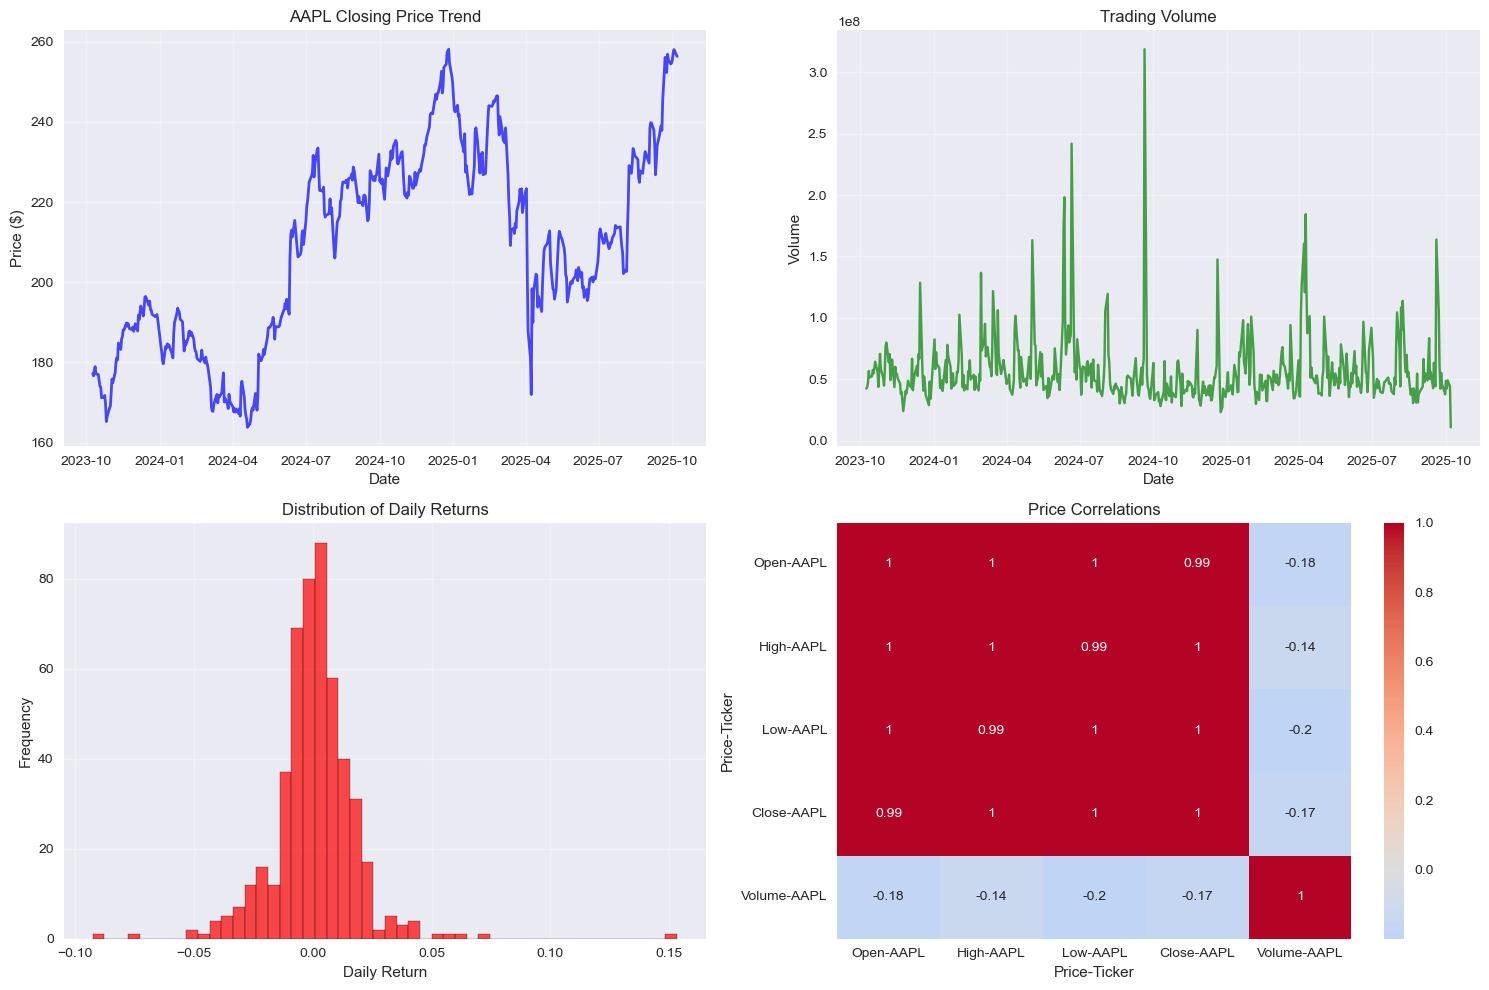


=== MOVING AVERAGES AND VOLATILITY ANALYSIS ===


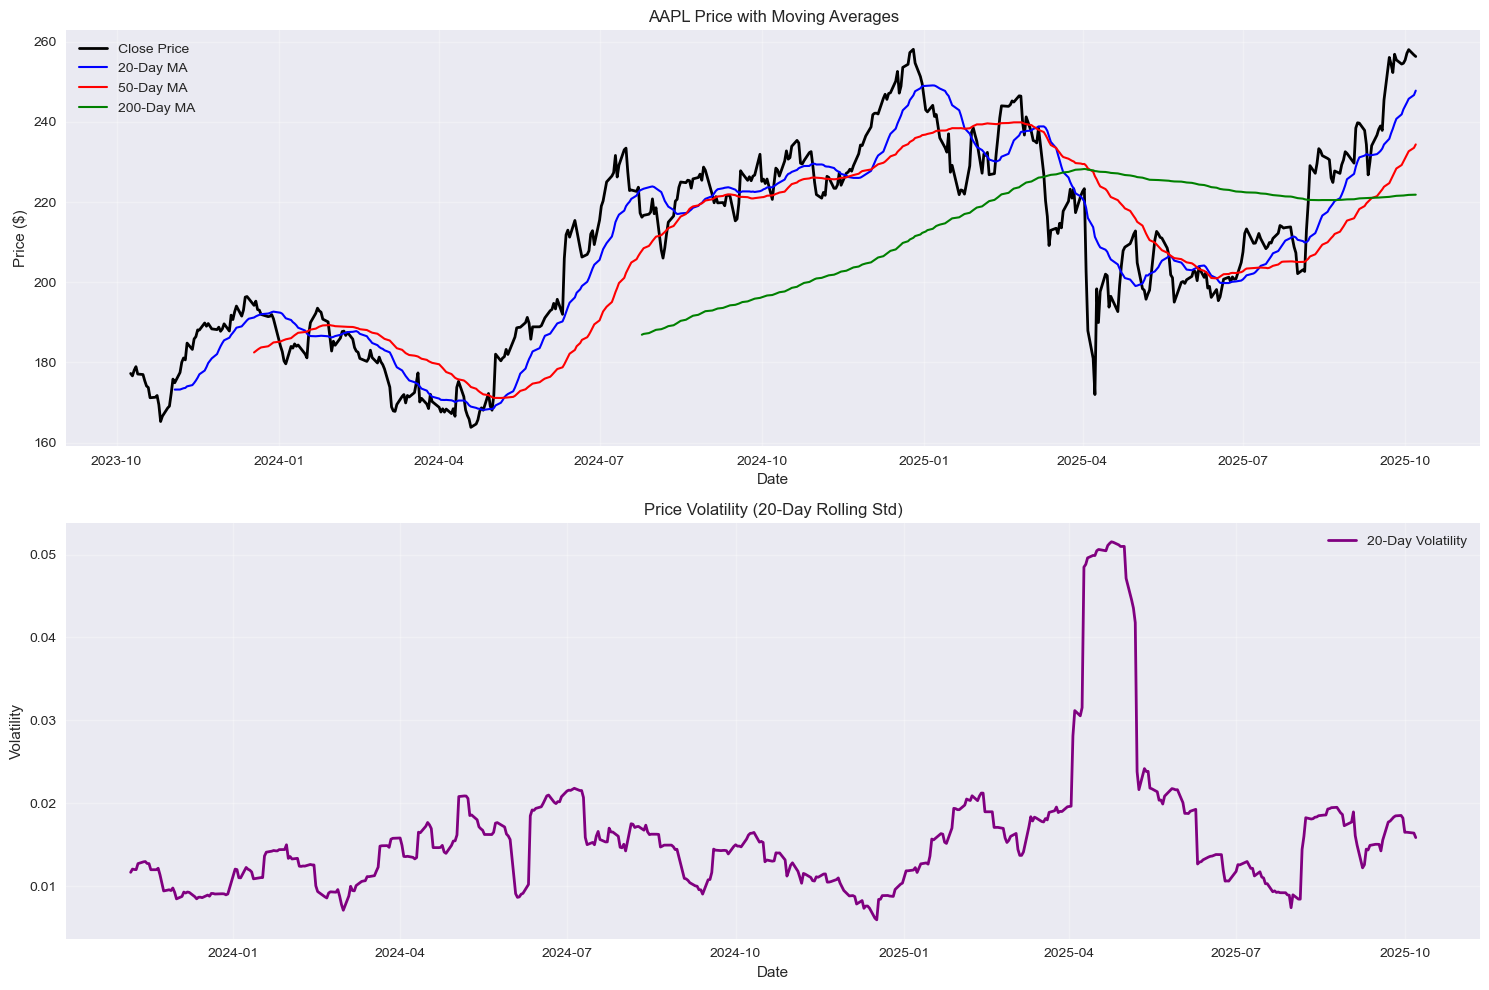


=== TECHNICAL INDICATORS ===


ValueError: Cannot set a DataFrame with multiple columns to the single column BB_Upper

In [7]:
# stock_market_analysis.py

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# ===== DATA COLLECTION =====
print("=== STOCK MARKET ANALYSIS ===")
print("Fetching data for AAPL (Apple Inc.)...")

# Fetch stock data
stock_data = yf.download('AAPL', period='2y')
print(f"Successfully fetched {len(stock_data)} days of data")

# Display basic info
print("\nData Overview:")
print(stock_data.head())
print(f"\nData Shape: {stock_data.shape}")
print(f"Date Range: {stock_data.index.min()} to {stock_data.index.max()}")

# ===== DATA EXPLORATION =====
print("\n=== DATA EXPLORATION ===")

# Check for missing values
print("Missing values:")
print(stock_data.isnull().sum())

# Basic statistics
print("\nBasic Statistics:")
print(stock_data.describe())

# ===== DATA PREPROCESSING =====
print("\n=== DATA PREPROCESSING ===")

# Handle missing values using interpolation
stock_data = stock_data.interpolate(method='time')
print("Missing values after interpolation:")
print(stock_data.isnull().sum())

# Add date features
stock_data['Day'] = stock_data.index.day
stock_data['Month'] = stock_data.index.month
stock_data['Year'] = stock_data.index.year
stock_data['DayOfWeek'] = stock_data.index.dayofweek

# ===== EXPLORATORY DATA ANALYSIS =====
print("\n=== EXPLORATORY DATA ANALYSIS ===")

# 1. Price Trends Over Time
plt.figure(figsize=(15, 10))

# Subplot 1: Closing Price
plt.subplot(2, 2, 1)
plt.plot(stock_data.index, stock_data['Close'], linewidth=2, color='blue', alpha=0.7)
plt.title('AAPL Closing Price Trend')
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.grid(True, alpha=0.3)

# Subplot 2: Volume
plt.subplot(2, 2, 2)
plt.plot(stock_data.index, stock_data['Volume'], color='green', alpha=0.7)
plt.title('Trading Volume')
plt.xlabel('Date')
plt.ylabel('Volume')
plt.grid(True, alpha=0.3)

# Subplot 3: Daily Returns
stock_data['Daily_Return'] = stock_data['Close'].pct_change()
plt.subplot(2, 2, 3)
plt.hist(stock_data['Daily_Return'].dropna(), bins=50, color='red', alpha=0.7, edgecolor='black')
plt.title('Distribution of Daily Returns')
plt.xlabel('Daily Return')
plt.ylabel('Frequency')
plt.grid(True, alpha=0.3)

# Subplot 4: Correlation Heatmap
plt.subplot(2, 2, 4)
numeric_columns = ['Open', 'High', 'Low', 'Close', 'Volume']
correlation_matrix = stock_data[numeric_columns].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Price Correlations')

plt.tight_layout()
plt.show()

# ===== MOVING AVERAGES AND VOLATILITY =====
print("\n=== MOVING AVERAGES AND VOLATILITY ANALYSIS ===")

# Calculate moving averages
stock_data['MA_20'] = stock_data['Close'].rolling(window=20).mean()
stock_data['MA_50'] = stock_data['Close'].rolling(window=50).mean()
stock_data['MA_200'] = stock_data['Close'].rolling(window=200).mean()

# Calculate volatility
stock_data['Volatility_20'] = stock_data['Daily_Return'].rolling(window=20).std()

# Plot Moving Averages
plt.figure(figsize=(15, 10))

plt.subplot(2, 1, 1)
plt.plot(stock_data.index, stock_data['Close'], label='Close Price', linewidth=2, color='black')
plt.plot(stock_data.index, stock_data['MA_20'], label='20-Day MA', linewidth=1.5, color='blue')
plt.plot(stock_data.index, stock_data['MA_50'], label='50-Day MA', linewidth=1.5, color='red')
plt.plot(stock_data.index, stock_data['MA_200'], label='200-Day MA', linewidth=1.5, color='green')
plt.title('AAPL Price with Moving Averages')
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(2, 1, 2)
plt.plot(stock_data.index, stock_data['Volatility_20'], label='20-Day Volatility', linewidth=2, color='purple')
plt.title('Price Volatility (20-Day Rolling Std)')
plt.xlabel('Date')
plt.ylabel('Volatility')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ===== TECHNICAL INDICATORS =====
print("\n=== TECHNICAL INDICATORS ===")

# Calculate RSI
delta = stock_data['Close'].diff()
gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
rs = gain / loss
stock_data['RSI'] = 100 - (100 / (1 + rs))

# Calculate MACD
exp1 = stock_data['Close'].ewm(span=12, adjust=False).mean()
exp2 = stock_data['Close'].ewm(span=26, adjust=False).mean()
stock_data['MACD'] = exp1 - exp2
stock_data['MACD_Signal'] = stock_data['MACD'].ewm(span=9, adjust=False).mean()

# Calculate Bollinger Bands
stock_data['BB_Middle'] = stock_data['Close'].rolling(window=20).mean()
bb_std = stock_data['Close'].rolling(window=20).std()
stock_data['BB_Upper'] = stock_data['BB_Middle'] + (bb_std * 2)
stock_data['BB_Lower'] = stock_data['BB_Middle'] - (bb_std * 2)

# Plot Technical Indicators
plt.figure(figsize=(15, 12))

# RSI
plt.subplot(3, 1, 1)
plt.plot(stock_data.index, stock_data['RSI'], linewidth=2, color='orange')
plt.axhline(70, linestyle='--', alpha=0.5, color='red', label='Overbought (70)')
plt.axhline(30, linestyle='--', alpha=0.5, color='green', label='Oversold (30)')
plt.title('Relative Strength Index (RSI)')
plt.ylabel('RSI')
plt.legend()
plt.grid(True, alpha=0.3)

# MACD
plt.subplot(3, 1, 2)
plt.plot(stock_data.index, stock_data['MACD'], label='MACD', linewidth=2, color='blue')
plt.plot(stock_data.index, stock_data['MACD_Signal'], label='Signal Line', linewidth=2, color='red')
plt.title('MACD Indicator')
plt.ylabel('MACD')
plt.legend()
plt.grid(True, alpha=0.3)

# Bollinger Bands
plt.subplot(3, 1, 3)
plt.plot(stock_data.index, stock_data['Close'], label='Close Price', linewidth=2, color='black')
plt.plot(stock_data.index, stock_data['BB_Upper'], label='Upper Band', linewidth=1, color='red', alpha=0.7)
plt.plot(stock_data.index, stock_data['BB_Middle'], label='Middle Band', linewidth=1, color='blue', alpha=0.7)
plt.plot(stock_data.index, stock_data['BB_Lower'], label='Lower Band', linewidth=1, color='green', alpha=0.7)
plt.fill_between(stock_data.index, stock_data['BB_Upper'], stock_data['BB_Lower'], alpha=0.1)
plt.title('Bollinger Bands')
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ===== MONTHLY AND WEEKLY ANALYSIS =====
print("\n=== SEASONAL ANALYSIS ===")

# Monthly performance
monthly_returns = stock_data.groupby('Month')['Daily_Return'].mean()

# Day of week performance
weekday_returns = stock_data.groupby('DayOfWeek')['Daily_Return'].mean()
weekday_names = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']

plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
plt.bar(months, monthly_returns, color='skyblue', edgecolor='black')
plt.title('Average Monthly Returns')
plt.ylabel('Average Return')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.bar(weekday_names, weekday_returns, color='lightgreen', edgecolor='black')
plt.title('Average Returns by Weekday')
plt.ylabel('Average Return')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ===== RISK ANALYSIS =====
print("\n=== RISK ANALYSIS ===")

# Calculate key metrics
total_return = (stock_data['Close'].iloc[-1] - stock_data['Close'].iloc[0]) / stock_data['Close'].iloc[0] * 100
avg_daily_return = stock_data['Daily_Return'].mean() * 100
volatility = stock_data['Daily_Return'].std() * 100
sharpe_ratio = (avg_daily_return / volatility) * np.sqrt(252) if volatility != 0 else 0

print(f"Total Return: {total_return:.2f}%")
print(f"Average Daily Return: {avg_daily_return:.3f}%")
print(f"Daily Volatility: {volatility:.3f}%")
print(f"Sharpe Ratio: {sharpe_ratio:.3f}")

# Drawdown analysis
stock_data['Cumulative_Return'] = (1 + stock_data['Daily_Return']).cumprod()
stock_data['Running_Max'] = stock_data['Cumulative_Return'].cummax()
stock_data['Drawdown'] = (stock_data['Cumulative_Return'] - stock_data['Running_Max']) / stock_data['Running_Max']

max_drawdown = stock_data['Drawdown'].min() * 100
print(f"Maximum Drawdown: {max_drawdown:.2f}%")

# Plot cumulative returns and drawdown
plt.figure(figsize=(15, 10))

plt.subplot(2, 1, 1)
plt.plot(stock_data.index, stock_data['Cumulative_Return'] * 100, linewidth=2, color='green')
plt.title('Cumulative Returns')
plt.ylabel('Return (%)')
plt.grid(True, alpha=0.3)

plt.subplot(2, 1, 2)
plt.fill_between(stock_data.index, stock_data['Drawdown'] * 100, 0, color='red', alpha=0.3)
plt.plot(stock_data.index, stock_data['Drawdown'] * 100, linewidth=1, color='red')
plt.title('Drawdown')
plt.xlabel('Date')
plt.ylabel('Drawdown (%)')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ===== CONCLUSION AND INSIGHTS =====
print("\n" + "="*50)
print("CONCLUSION AND INVESTMENT INSIGHTS")
print("="*50)

print(f"\nANALYSIS SUMMARY FOR AAPL:")
print(f"• Analysis Period: {stock_data.index.min().strftime('%Y-%m-%d')} to {stock_data.index.max().strftime('%Y-%m-%d')}")
print(f"• Total Return: {total_return:.2f}%")
print(f"• Risk Level: {'High' if volatility > 2 else 'Medium' if volatility > 1 else 'Low'}")
print(f"• Maximum Drawdown: {max_drawdown:.2f}%")

# Current technical signals
current_rsi = stock_data['RSI'].iloc[-1]
current_macd = stock_data['MACD'].iloc[-1]
current_macd_signal = stock_data['MACD_Signal'].iloc[-1]

print(f"\nCURRENT TECHNICAL SIGNALS:")
print(f"• RSI: {current_rsi:.1f} - {'Overbought' if current_rsi > 70 else 'Oversold' if current_rsi < 30 else 'Neutral'}")
print(f"• MACD: {current_macd:.2f} - {'Bullish' if current_macd > current_macd_signal else 'Bearish'}")

print(f"\nRECOMMENDATIONS:")
if current_rsi < 30 and current_macd > current_macd_signal:
    print("• STRONG BUY SIGNAL: Oversold with bullish MACD crossover")
elif current_rsi > 70 and current_macd < current_macd_signal:
    print("• STRONG SELL SIGNAL: Overbought with bearish MACD crossover")
elif current_rsi < 40 and current_macd > current_macd_signal:
    print("• MODERATE BUY SIGNAL: Approaching oversold with bullish momentum")
elif current_rsi > 60 and current_macd < current_macd_signal:
    print("• MODERATE SELL SIGNAL: Approaching overbought with bearish momentum")
else:
    print("• HOLD: Mixed or neutral signals")

print(f"\nRISK MANAGEMENT STRATEGIES:")
print("• Consider position sizing based on volatility")
print("• Use stop-loss orders to limit downside risk")
print("• Diversify across sectors to reduce concentration risk")
print("• Monitor key technical levels for entry/exit points")

print("\n" + "="*50)
print("ANALYSIS COMPLETED SUCCESSFULLY!")
print("="*50)

=== STOCK MARKET ANALYSIS ===
Fetching data for AAPL (Apple Inc.)...


[*********************100%***********************]  1 of 1 completed


Successfully fetched 501 days of data

Data Overview:
Price            Close        High         Low        Open    Volume
Ticker            AAPL        AAPL        AAPL        AAPL      AAPL
Date                                                                
2023-10-09  177.253815  177.313230  174.094755  175.094953  42390800
2023-10-10  176.659622  177.976723  176.223888  176.372442  43698000
2023-10-11  178.055954  178.105472  175.877297  176.471468  47551100
2023-10-12  178.957123  180.571302  177.303308  178.323331  56743100
2023-10-13  177.115189  180.165300  176.412069  179.660252  51427100

Data Shape: (501, 5)
Date Range: 2023-10-09 00:00:00 to 2025-10-07 00:00:00

=== DATA EXPLORATION ===
Missing values:
Price   Ticker
Close   AAPL      0
High    AAPL      0
Low     AAPL      0
Open    AAPL      0
Volume  AAPL      0
dtype: int64

Basic Statistics:
Price        Close        High         Low        Open        Volume
Ticker        AAPL        AAPL        AAPL        AAPL     

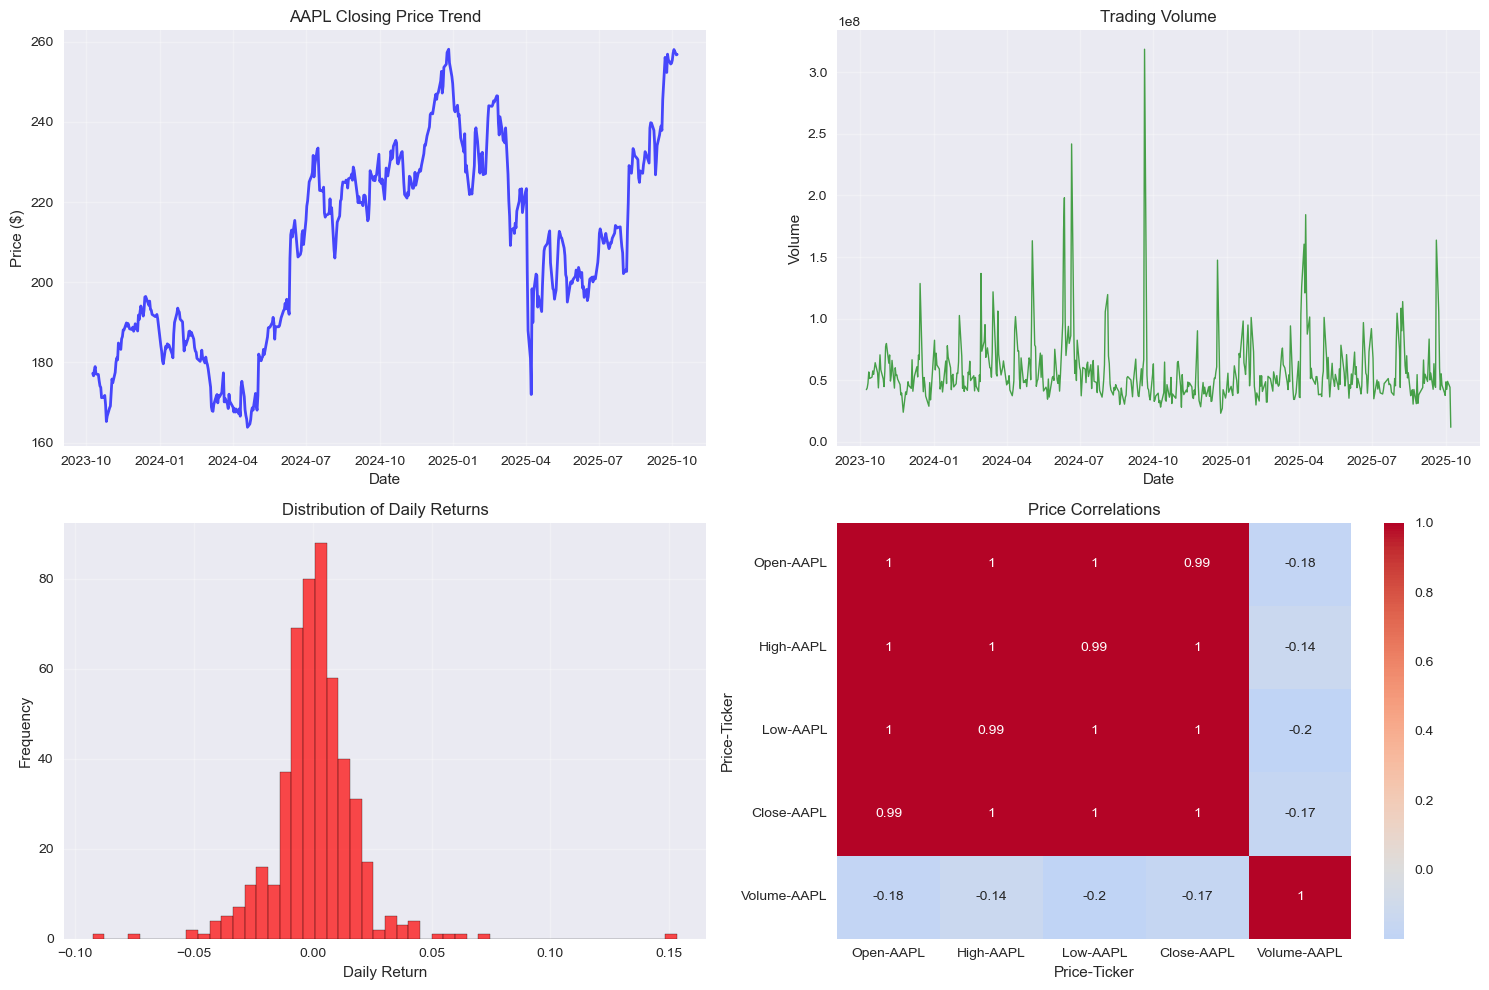


=== MOVING AVERAGES AND VOLATILITY ANALYSIS ===


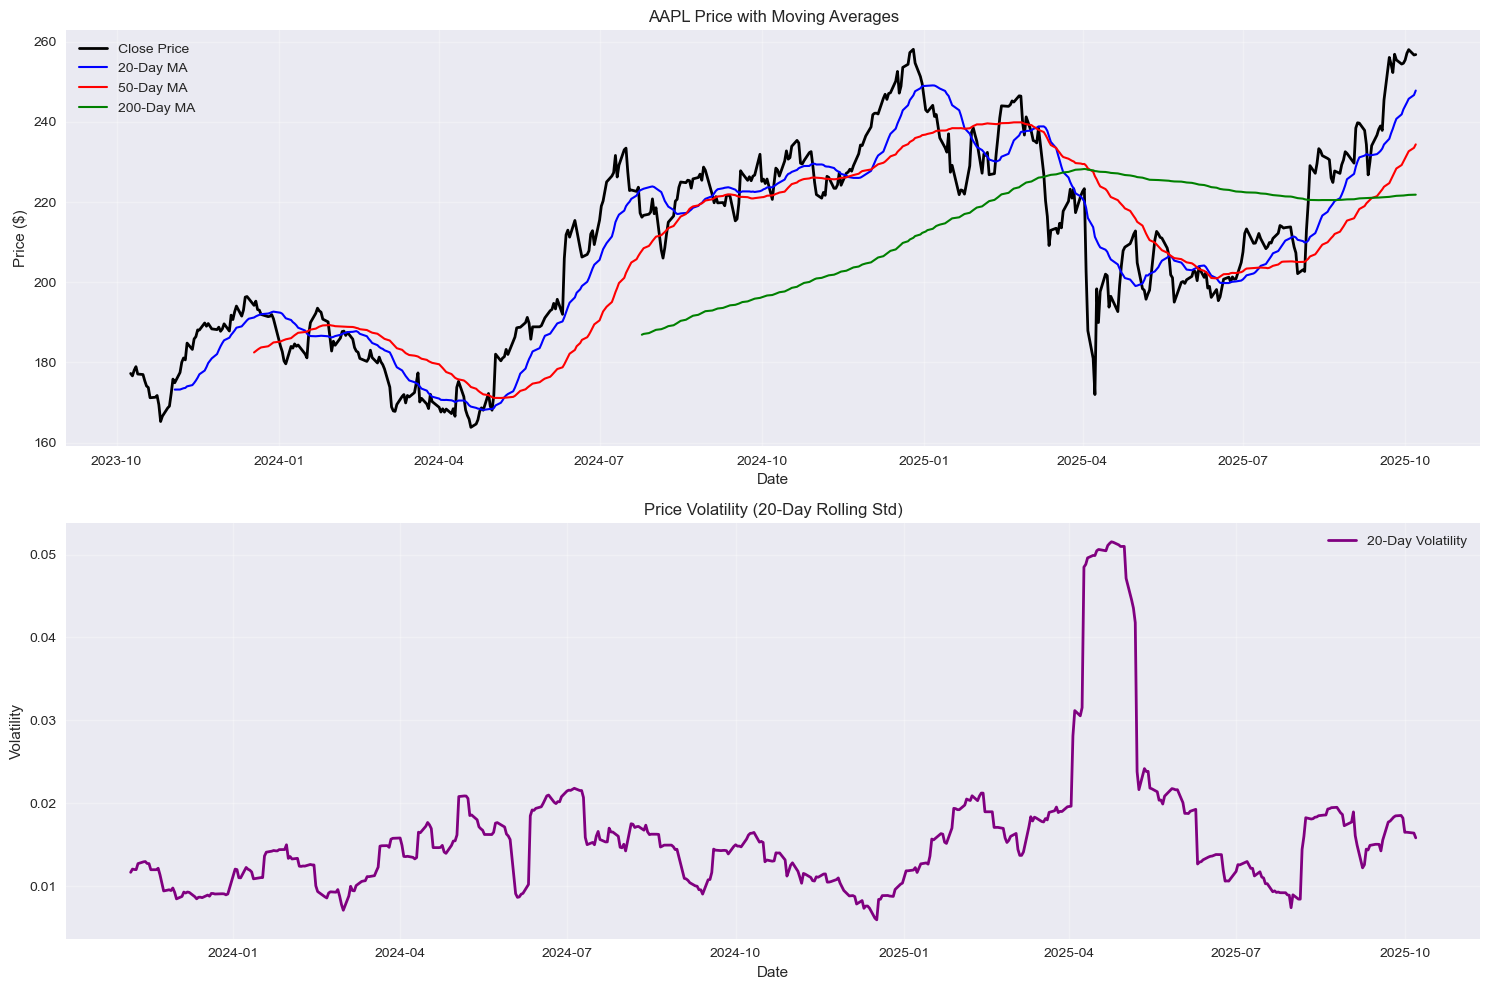


=== TECHNICAL INDICATORS ===


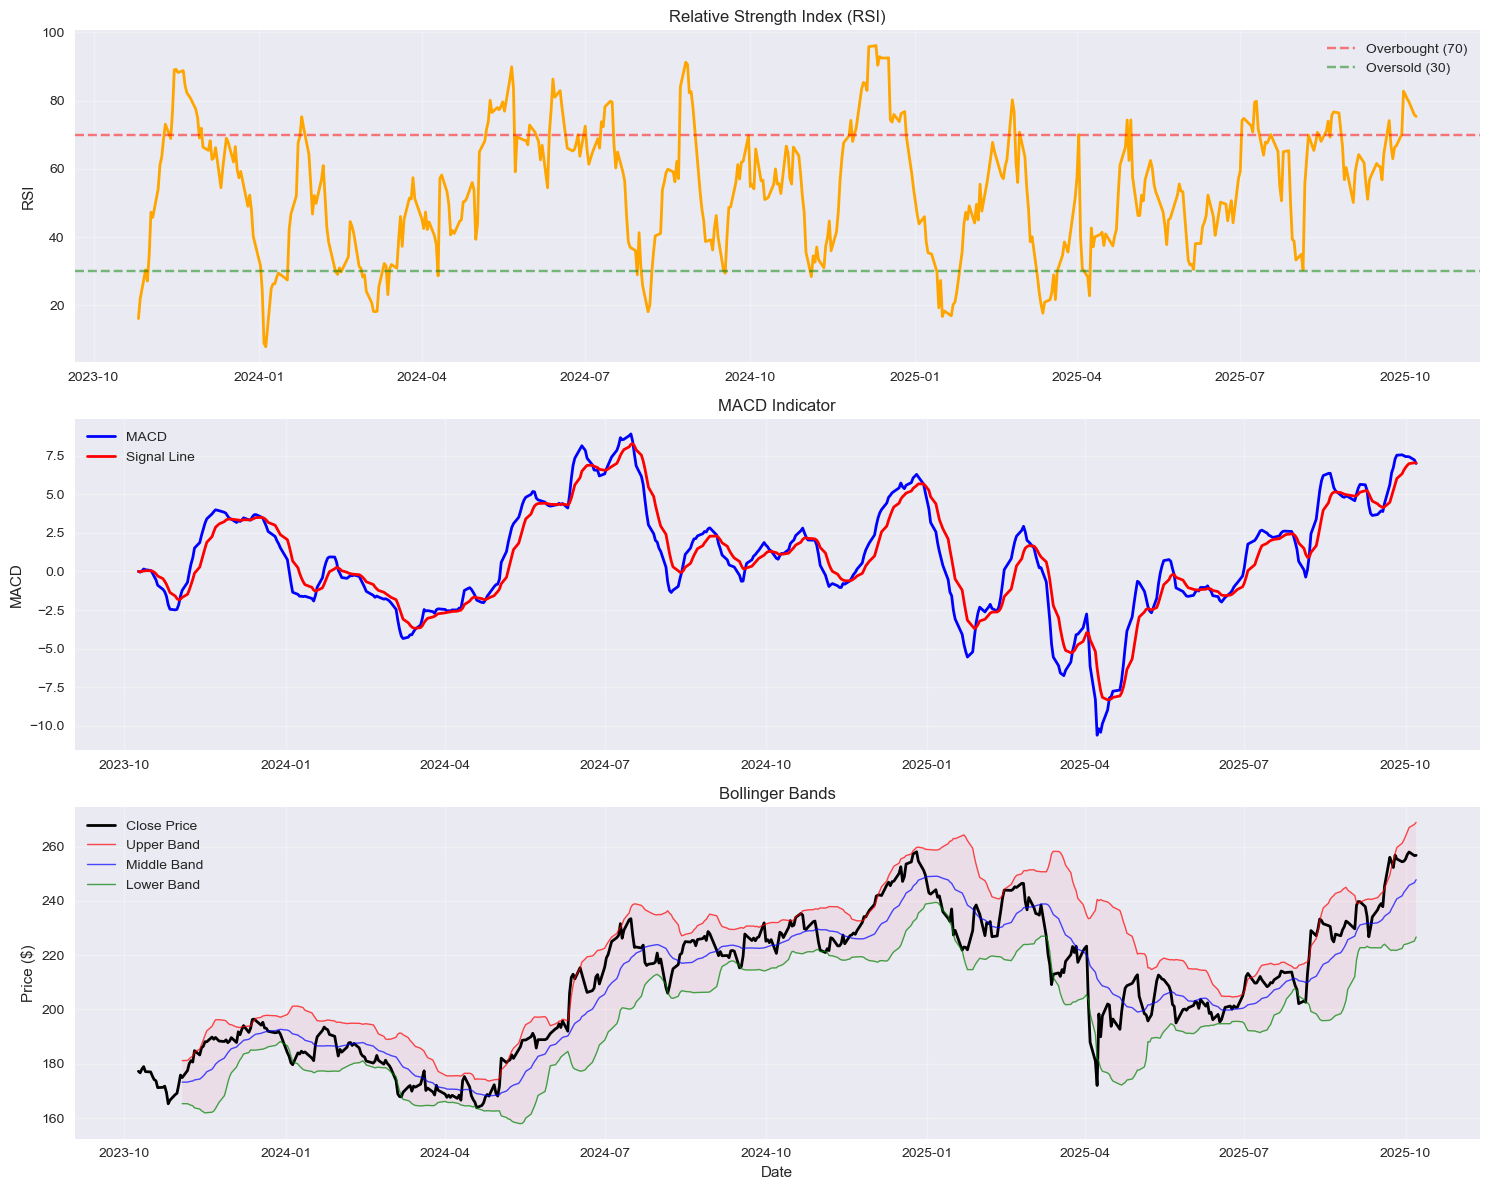


=== SEASONAL ANALYSIS ===


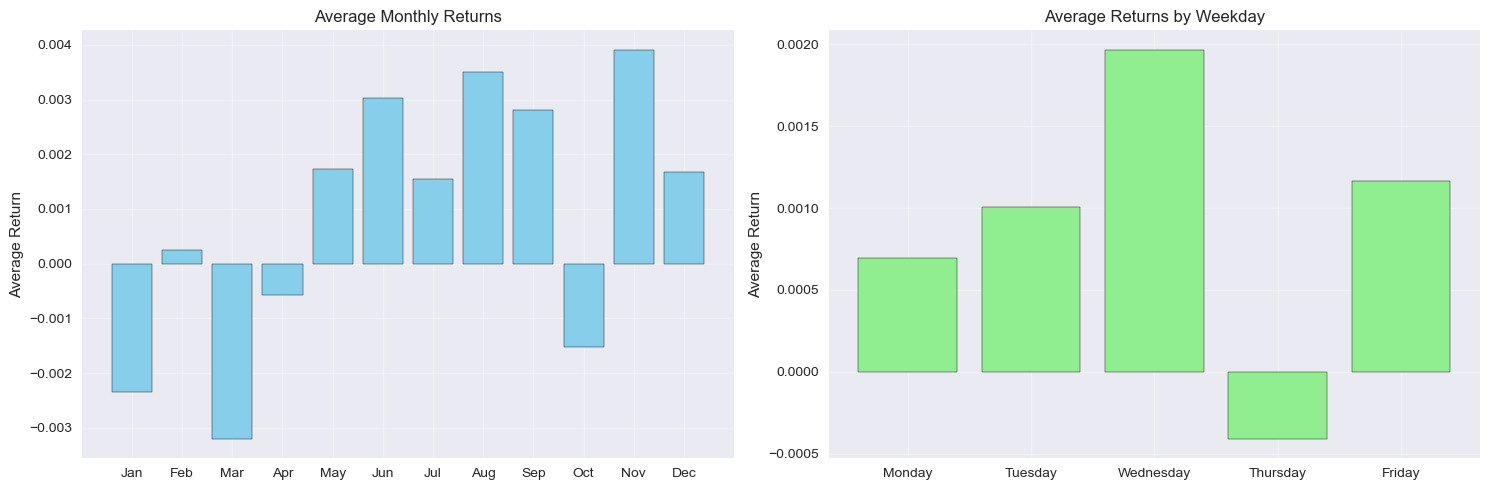


=== RISK ANALYSIS ===
Total Return: 44.87%
Average Daily Return: 0.089%
Daily Volatility: 1.755%
Sharpe Ratio: 0.808
Maximum Drawdown: -33.36%


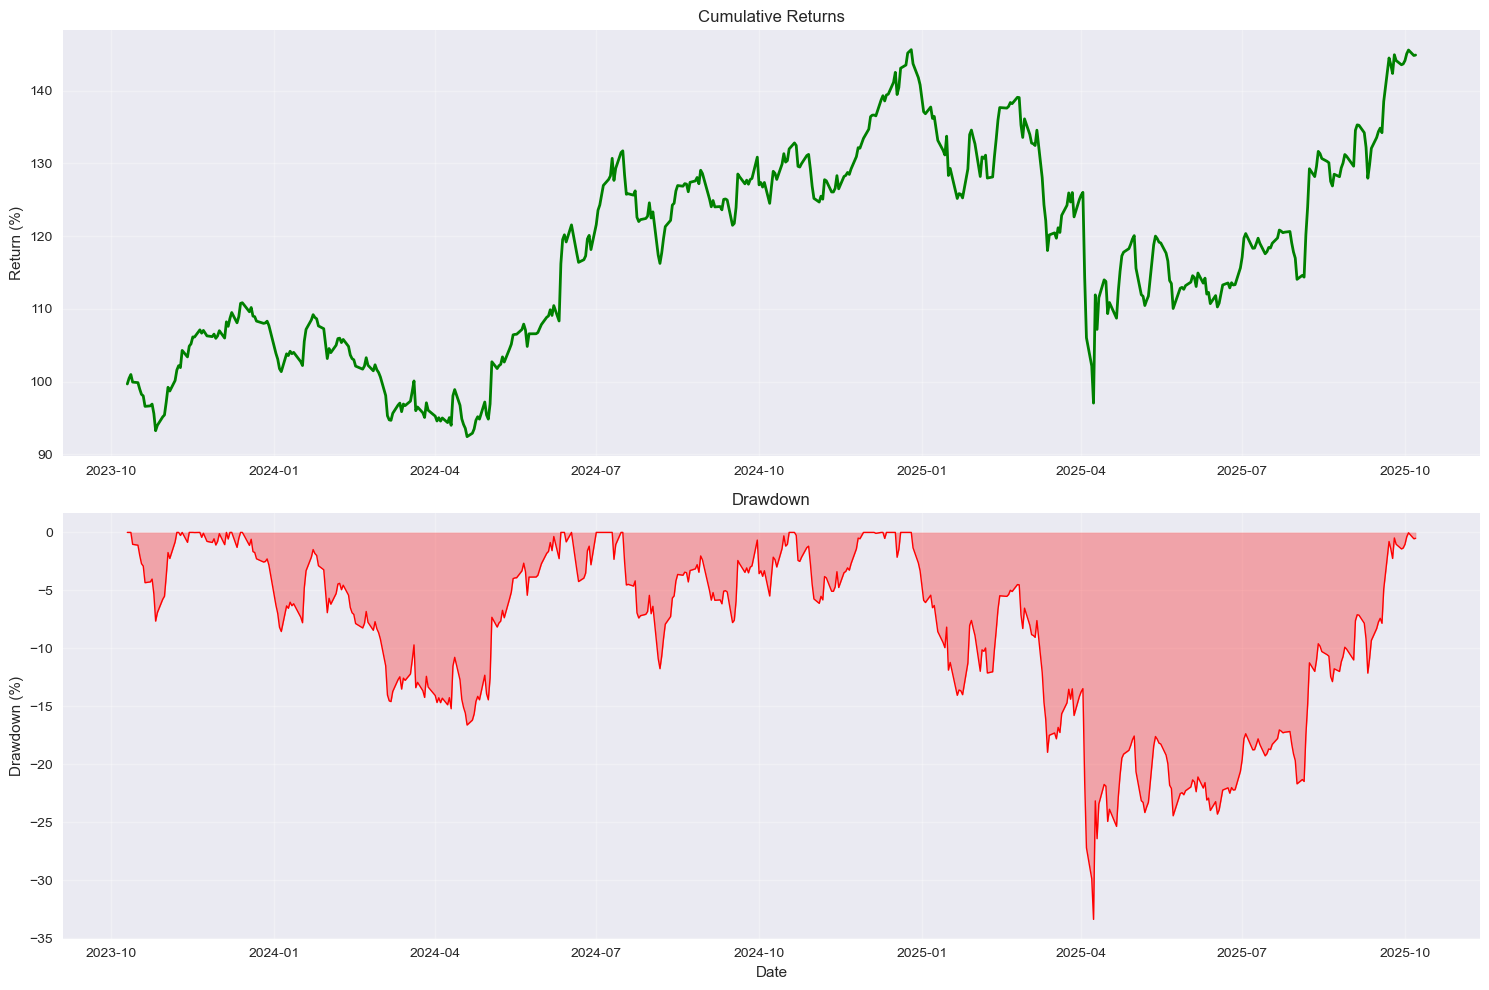


CONCLUSION AND INVESTMENT INSIGHTS

ANALYSIS SUMMARY FOR AAPL:
• Analysis Period: 2023-10-09 to 2025-10-07
• Total Return: 44.87%
• Risk Level: Medium
• Maximum Drawdown: -33.36%

CURRENT TECHNICAL SIGNALS:
• RSI: 75.4 - Overbought
• MACD: 6.99 - Bearish

RECOMMENDATIONS:
• STRONG SELL SIGNAL: Overbought with bearish MACD crossover

RISK MANAGEMENT STRATEGIES:
• Consider position sizing based on volatility
• Use stop-loss orders to limit downside risk
• Diversify across sectors to reduce concentration risk
• Monitor key technical levels for entry/exit points

ANALYSIS COMPLETED SUCCESSFULLY!


In [15]:
# stock_market_analysis.py

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# ===== DATA COLLECTION =====
print("=== STOCK MARKET ANALYSIS ===")
print("Fetching data for AAPL (Apple Inc.)...")

# Fetch stock data
stock_data = yf.download('AAPL', period='2y')
print(f"Successfully fetched {len(stock_data)} days of data")

# Display basic info
print("\nData Overview:")
print(stock_data.head())
print(f"\nData Shape: {stock_data.shape}")
print(f"Date Range: {stock_data.index.min()} to {stock_data.index.max()}")

# ===== DATA EXPLORATION =====
print("\n=== DATA EXPLORATION ===")

# Check for missing values
print("Missing values:")
print(stock_data.isnull().sum())

# Basic statistics
print("\nBasic Statistics:")
print(stock_data.describe())

# ===== DATA PREPROCESSING =====
print("\n=== DATA PREPROCESSING ===")

# Handle missing values using interpolation
stock_data = stock_data.interpolate(method='time')
print("Missing values after interpolation:")
print(stock_data.isnull().sum())

# Add date features
stock_data['Day'] = stock_data.index.day
stock_data['Month'] = stock_data.index.month
stock_data['Year'] = stock_data.index.year
stock_data['DayOfWeek'] = stock_data.index.dayofweek

# ===== EXPLORATORY DATA ANALYSIS =====
print("\n=== EXPLORATORY DATA ANALYSIS ===")

# 1. Price Trends Over Time
plt.figure(figsize=(15, 10))

# Subplot 1: Closing Price
plt.subplot(2, 2, 1)
plt.plot(stock_data.index, stock_data['Close'], linewidth=2, color='blue', alpha=0.7)
plt.title('AAPL Closing Price Trend')
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.grid(True, alpha=0.3)

# Subplot 2: Volume - FIXED: Using plot instead of bar for better visualization
plt.subplot(2, 2, 2)
plt.plot(stock_data.index, stock_data['Volume'], color='green', alpha=0.7, linewidth=1)
plt.title('Trading Volume')
plt.xlabel('Date')
plt.ylabel('Volume')
plt.grid(True, alpha=0.3)

# Subplot 3: Daily Returns
stock_data['Daily_Return'] = stock_data['Close'].pct_change()
plt.subplot(2, 2, 3)
plt.hist(stock_data['Daily_Return'].dropna(), bins=50, color='red', alpha=0.7, edgecolor='black')
plt.title('Distribution of Daily Returns')
plt.xlabel('Daily Return')
plt.ylabel('Frequency')
plt.grid(True, alpha=0.3)

# Subplot 4: Correlation Heatmap
plt.subplot(2, 2, 4)
numeric_columns = ['Open', 'High', 'Low', 'Close', 'Volume']
correlation_matrix = stock_data[numeric_columns].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Price Correlations')

plt.tight_layout()
plt.show()

# ===== MOVING AVERAGES AND VOLATILITY =====
print("\n=== MOVING AVERAGES AND VOLATILITY ANALYSIS ===")

# Calculate moving averages
stock_data['MA_20'] = stock_data['Close'].rolling(window=20).mean()
stock_data['MA_50'] = stock_data['Close'].rolling(window=50).mean()
stock_data['MA_200'] = stock_data['Close'].rolling(window=200).mean()

# Calculate volatility
stock_data['Volatility_20'] = stock_data['Daily_Return'].rolling(window=20).std()

# Plot Moving Averages
plt.figure(figsize=(15, 10))

plt.subplot(2, 1, 1)
plt.plot(stock_data.index, stock_data['Close'], label='Close Price', linewidth=2, color='black')
plt.plot(stock_data.index, stock_data['MA_20'], label='20-Day MA', linewidth=1.5, color='blue')
plt.plot(stock_data.index, stock_data['MA_50'], label='50-Day MA', linewidth=1.5, color='red')
plt.plot(stock_data.index, stock_data['MA_200'], label='200-Day MA', linewidth=1.5, color='green')
plt.title('AAPL Price with Moving Averages')
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(2, 1, 2)
plt.plot(stock_data.index, stock_data['Volatility_20'], label='20-Day Volatility', linewidth=2, color='purple')
plt.title('Price Volatility (20-Day Rolling Std)')
plt.xlabel('Date')
plt.ylabel('Volatility')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ===== TECHNICAL INDICATORS =====
print("\n=== TECHNICAL INDICATORS ===")

# Calculate RSI
delta = stock_data['Close'].diff()
gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
rs = gain / loss
stock_data['RSI'] = 100 - (100 / (1 + rs))

# Calculate MACD
exp1 = stock_data['Close'].ewm(span=12, adjust=False).mean()
exp2 = stock_data['Close'].ewm(span=26, adjust=False).mean()
stock_data['MACD'] = exp1 - exp2
stock_data['MACD_Signal'] = stock_data['MACD'].ewm(span=9, adjust=False).mean()

# Calculate Bollinger Bands - FIXED: Proper single column assignment
bb_middle = stock_data['Close'].rolling(window=20).mean()
bb_std = stock_data['Close'].rolling(window=20).std()
stock_data['BB_Upper'] = bb_middle + (bb_std * 2)
stock_data['BB_Lower'] = bb_middle - (bb_std * 2)
stock_data['BB_Middle'] = bb_middle

# Plot Technical Indicators
plt.figure(figsize=(15, 12))

# RSI
plt.subplot(3, 1, 1)
plt.plot(stock_data.index, stock_data['RSI'], linewidth=2, color='orange')
plt.axhline(70, linestyle='--', alpha=0.5, color='red', label='Overbought (70)')
plt.axhline(30, linestyle='--', alpha=0.5, color='green', label='Oversold (30)')
plt.title('Relative Strength Index (RSI)')
plt.ylabel('RSI')
plt.legend()
plt.grid(True, alpha=0.3)

# MACD
plt.subplot(3, 1, 2)
plt.plot(stock_data.index, stock_data['MACD'], label='MACD', linewidth=2, color='blue')
plt.plot(stock_data.index, stock_data['MACD_Signal'], label='Signal Line', linewidth=2, color='red')
plt.title('MACD Indicator')
plt.ylabel('MACD')
plt.legend()
plt.grid(True, alpha=0.3)

# Bollinger Bands
plt.subplot(3, 1, 3)
plt.plot(stock_data.index, stock_data['Close'], label='Close Price', linewidth=2, color='black')
plt.plot(stock_data.index, stock_data['BB_Upper'], label='Upper Band', linewidth=1, color='red', alpha=0.7)
plt.plot(stock_data.index, stock_data['BB_Middle'], label='Middle Band', linewidth=1, color='blue', alpha=0.7)
plt.plot(stock_data.index, stock_data['BB_Lower'], label='Lower Band', linewidth=1, color='green', alpha=0.7)
plt.fill_between(stock_data.index, stock_data['BB_Upper'], stock_data['BB_Lower'], alpha=0.1)
plt.title('Bollinger Bands')
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ===== MONTHLY AND WEEKLY ANALYSIS =====
print("\n=== SEASONAL ANALYSIS ===")

# Monthly performance
monthly_returns = stock_data.groupby('Month')['Daily_Return'].mean()

# Day of week performance
weekday_returns = stock_data.groupby('DayOfWeek')['Daily_Return'].mean()
weekday_names = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']

plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
plt.bar(months, monthly_returns, color='skyblue', edgecolor='black')
plt.title('Average Monthly Returns')
plt.ylabel('Average Return')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.bar(weekday_names, weekday_returns, color='lightgreen', edgecolor='black')
plt.title('Average Returns by Weekday')
plt.ylabel('Average Return')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ===== RISK ANALYSIS =====
print("\n=== RISK ANALYSIS ===")

# Calculate key metrics - FIXED: Ensure we get scalar values
total_return = float((stock_data['Close'].iloc[-1] - stock_data['Close'].iloc[0]) / stock_data['Close'].iloc[0] * 100)
avg_daily_return = float(stock_data['Daily_Return'].mean() * 100)
volatility = float(stock_data['Daily_Return'].std() * 100)
sharpe_ratio = float((avg_daily_return / volatility) * np.sqrt(252)) if volatility != 0 else 0

print(f"Total Return: {total_return:.2f}%")
print(f"Average Daily Return: {avg_daily_return:.3f}%")
print(f"Daily Volatility: {volatility:.3f}%")
print(f"Sharpe Ratio: {sharpe_ratio:.3f}")

# Drawdown analysis
stock_data['Cumulative_Return'] = (1 + stock_data['Daily_Return']).cumprod()
stock_data['Running_Max'] = stock_data['Cumulative_Return'].cummax()
stock_data['Drawdown'] = (stock_data['Cumulative_Return'] - stock_data['Running_Max']) / stock_data['Running_Max']

max_drawdown = float(stock_data['Drawdown'].min() * 100)
print(f"Maximum Drawdown: {max_drawdown:.2f}%")

# Plot cumulative returns and drawdown
plt.figure(figsize=(15, 10))

plt.subplot(2, 1, 1)
plt.plot(stock_data.index, stock_data['Cumulative_Return'] * 100, linewidth=2, color='green')
plt.title('Cumulative Returns')
plt.ylabel('Return (%)')
plt.grid(True, alpha=0.3)

plt.subplot(2, 1, 2)
plt.fill_between(stock_data.index, stock_data['Drawdown'] * 100, 0, color='red', alpha=0.3)
plt.plot(stock_data.index, stock_data['Drawdown'] * 100, linewidth=1, color='red')
plt.title('Drawdown')
plt.xlabel('Date')
plt.ylabel('Drawdown (%)')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ===== CONCLUSION AND INSIGHTS =====
print("\n" + "="*50)
print("CONCLUSION AND INVESTMENT INSIGHTS")
print("="*50)

print(f"\nANALYSIS SUMMARY FOR AAPL:")
print(f"• Analysis Period: {stock_data.index.min().strftime('%Y-%m-%d')} to {stock_data.index.max().strftime('%Y-%m-%d')}")
print(f"• Total Return: {total_return:.2f}%")
print(f"• Risk Level: {'High' if volatility > 2 else 'Medium' if volatility > 1 else 'Low'}")
print(f"• Maximum Drawdown: {max_drawdown:.2f}%")

# Current technical signals - FIXED: Ensure scalar values
current_rsi = float(stock_data['RSI'].iloc[-1])
current_macd = float(stock_data['MACD'].iloc[-1])
current_macd_signal = float(stock_data['MACD_Signal'].iloc[-1])

print(f"\nCURRENT TECHNICAL SIGNALS:")
print(f"• RSI: {current_rsi:.1f} - {'Overbought' if current_rsi > 70 else 'Oversold' if current_rsi < 30 else 'Neutral'}")
print(f"• MACD: {current_macd:.2f} - {'Bullish' if current_macd > current_macd_signal else 'Bearish'}")

print(f"\nRECOMMENDATIONS:")
if current_rsi < 30 and current_macd > current_macd_signal:
    print("• STRONG BUY SIGNAL: Oversold with bullish MACD crossover")
elif current_rsi > 70 and current_macd < current_macd_signal:
    print("• STRONG SELL SIGNAL: Overbought with bearish MACD crossover")
elif current_rsi < 40 and current_macd > current_macd_signal:
    print("• MODERATE BUY SIGNAL: Approaching oversold with bullish momentum")
elif current_rsi > 60 and current_macd < current_macd_signal:
    print("• MODERATE SELL SIGNAL: Approaching overbought with bearish momentum")
else:
    print("• HOLD: Mixed or neutral signals")

print(f"\nRISK MANAGEMENT STRATEGIES:")
print("• Consider position sizing based on volatility")
print("• Use stop-loss orders to limit downside risk")
print("• Diversify across sectors to reduce concentration risk")
print("• Monitor key technical levels for entry/exit points")

print("\n" + "="*50)
print("ANALYSIS COMPLETED SUCCESSFULLY!")
print("="*50)

In [11]:
# ===== RISK ANALYSIS =====
print("\n=== RISK ANALYSIS ===")

# Calculate key metrics
total_return = (stock_data['Close'].iloc[-1] - stock_data['Close'].iloc[0]) / stock_data['Close'].iloc[0] * 100
avg_daily_return = stock_data['Daily_Return'].mean() * 100
volatility = stock_data['Daily_Return'].std() * 100
sharpe_ratio = (avg_daily_return / volatility) * np.sqrt(252) if volatility != 0 else 0

print(f"Total Return: {total_return:.2f}%")
print(f"Average Daily Return: {avg_daily_return:.3f}%")
print(f"Daily Volatility: {volatility:.3f}%")
print(f"Sharpe Ratio: {sharpe_ratio:.3f}")

# Drawdown analysis
stock_data['Cumulative_Return'] = (1 + stock_data['Daily_Return']).cumprod()
stock_data['Running_Max'] = stock_data['Cumulative_Return'].cummax()
stock_data['Drawdown'] = (stock_data['Cumulative_Return'] - stock_data['Running_Max']) / stock_data['Running_Max']

max_drawdown = stock_data['Drawdown'].min() * 100
print(f"Maximum Drawdown: {max_drawdown:.2f}%")

# Plot cumulative returns and drawdown
plt.figure(figsize=(15, 10))

plt.subplot(2, 1, 1)
plt.plot(stock_data.index, stock_data['Cumulative_Return'] * 100, linewidth=2, color='green')
plt.title('Cumulative Returns')
plt.ylabel('Return (%)')
plt.grid(True, alpha=0.3)

plt.subplot(2, 1, 2)
plt.fill_between(stock_data.index, stock_data['Drawdown'] * 100, 0, color='red', alpha=0.3)
plt.plot(stock_data.index, stock_data['Drawdown'] * 100, linewidth=1, color='red')
plt.title('Drawdown')
plt.xlabel('Date')
plt.ylabel('Drawdown (%)')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ===== CONCLUSION AND INSIGHTS =====
print("\n" + "="*50)
print("CONCLUSION AND INVESTMENT INSIGHTS")
print("="*50)

print(f"\nANALYSIS SUMMARY FOR AAPL:")
print(f"• Analysis Period: {stock_data.index.min().strftime('%Y-%m-%d')} to {stock_data.index.max().strftime('%Y-%m-%d')}")
print(f"• Total Return: {total_return:.2f}%")
print(f"• Risk Level: {'High' if volatility > 2 else 'Medium' if volatility > 1 else 'Low'}")
print(f"• Maximum Drawdown: {max_drawdown:.2f}%")

# Current technical signals
current_rsi = stock_data['RSI'].iloc[-1]
current_macd = stock_data['MACD'].iloc[-1]
current_macd_signal = stock_data['MACD_Signal'].iloc[-1]

print(f"\nCURRENT TECHNICAL SIGNALS:")
print(f"• RSI: {current_rsi:.1f} - {'Overbought' if current_rsi > 70 else 'Oversold' if current_rsi < 30 else 'Neutral'}")
print(f"• MACD: {current_macd:.2f} - {'Bullish' if current_macd > current_macd_signal else 'Bearish'}")

print(f"\nRECOMMENDATIONS:")
if current_rsi < 30 and current_macd > current_macd_signal:
    print("• STRONG BUY SIGNAL: Oversold with bullish MACD crossover")
elif current_rsi > 70 and current_macd < current_macd_signal:
    print("• STRONG SELL SIGNAL: Overbought with bearish MACD crossover")
elif current_rsi < 40 and current_macd > current_macd_signal:
    print("• MODERATE BUY SIGNAL: Approaching oversold with bullish momentum")
elif current_rsi > 60 and current_macd < current_macd_signal:
    print("• MODERATE SELL SIGNAL: Approaching overbought with bearish momentum")
else:
    print("• HOLD: Mixed or neutral signals")

print(f"\nRISK MANAGEMENT STRATEGIES:")
print("• Consider position sizing based on volatility")
print("• Use stop-loss orders to limit downside risk")
print("• Diversify across sectors to reduce concentration risk")
print("• Monitor key technical levels for entry/exit points")

print("\n" + "="*50)
print("ANALYSIS COMPLETED SUCCESSFULLY!")
print("="*50)


=== RISK ANALYSIS ===


TypeError: unsupported format string passed to Series.__format__

In [12]:
# ===== RISK ANALYSIS =====
print("\n=== RISK ANALYSIS ===")

# Calculate key metrics
total_return = (stock_data['Close'].iloc[-1] - stock_data['Close'].iloc[0]) / stock_data['Close'].iloc[0] * 100
avg_daily_return = stock_data['Daily_Return'].mean() * 100
volatility = stock_data['Daily_Return'].std() * 100
sharpe_ratio = (avg_daily_return / volatility) * np.sqrt(252) if volatility != 0 else 0

print(f"Total Return: {total_return:.2f}%")
print(f"Average Daily Return: {avg_daily_return:.3f}%")
print(f"Daily Volatility: {volatility:.3f}%")
print(f"Sharpe Ratio: {sharpe_ratio:.3f}")

# Drawdown analysis
stock_data['Cumulative_Return'] = (1 + stock_data['Daily_Return']).cumprod()
stock_data['Running_Max'] = stock_data['Cumulative_Return'].cummax()
stock_data['Drawdown'] = (stock_data['Cumulative_Return'] - stock_data['Running_Max']) / stock_data['Running_Max']

max_drawdown = stock_data['Drawdown'].min() * 100
print(f"Maximum Drawdown: {max_drawdown:.2f}%")

# Plot cumulative returns and drawdown
plt.figure(figsize=(15, 10))

plt.subplot(2, 1, 1)
plt.plot(stock_data.index, stock_data['Cumulative_Return'] * 100, linewidth=2, color='green')
plt.title('Cumulative Returns')
plt.ylabel('Return (%)')
plt.grid(True, alpha=0.3)

plt.subplot(2, 1, 2)
plt.fill_between(stock_data.index, stock_data['Drawdown'] * 100, 0, color='red', alpha=0.3)
plt.plot(stock_data.index, stock_data['Drawdown'] * 100, linewidth=1, color='red')
plt.title('Drawdown')
plt.xlabel('Date')
plt.ylabel('Drawdown (%)')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ===== CONCLUSION AND INSIGHTS =====
print("\n" + "="*50)
print("CONCLUSION AND INVESTMENT INSIGHTS")
print("="*50)

print(f"\nANALYSIS SUMMARY FOR AAPL:")
print(f"• Analysis Period: {stock_data.index.min().strftime('%Y-%m-%d')} to {stock_data.index.max().strftime('%Y-%m-%d')}")
print(f"• Total Return: {total_return:.2f}%")
print(f"• Risk Level: {'High' if volatility > 2 else 'Medium' if volatility > 1 else 'Low'}")
print(f"• Maximum Drawdown: {max_drawdown:.2f}%")

# Current technical signals
current_rsi = stock_data['RSI'].iloc[-1]
current_macd = stock_data['MACD'].iloc[-1]
current_macd_signal = stock_data['MACD_Signal'].iloc[-1]

print(f"\nCURRENT TECHNICAL SIGNALS:")
print(f"• RSI: {current_rsi:.1f} - {'Overbought' if current_rsi > 70 else 'Oversold' if current_rsi < 30 else 'Neutral'}")
print(f"• MACD: {current_macd:.2f} - {'Bullish' if current_macd > current_macd_signal else 'Bearish'}")

print(f"\nRECOMMENDATIONS:")
if current_rsi < 30 and current_macd > current_macd_signal:
    print("• STRONG BUY SIGNAL: Oversold with bullish MACD crossover")
elif current_rsi > 70 and current_macd < current_macd_signal:
    print("• STRONG SELL SIGNAL: Overbought with bearish MACD crossover")
elif current_rsi < 40 and current_macd > current_macd_signal:
    print("• MODERATE BUY SIGNAL: Approaching oversold with bullish momentum")
elif current_rsi > 60 and current_macd < current_macd_signal:
    print("• MODERATE SELL SIGNAL: Approaching overbought with bearish momentum")
else:
    print("• HOLD: Mixed or neutral signals")

print(f"\nRISK MANAGEMENT STRATEGIES:")
print("• Consider position sizing based on volatility")
print("• Use stop-loss orders to limit downside risk")
print("• Diversify across sectors to reduce concentration risk")
print("• Monitor key technical levels for entry/exit points")

print("\n" + "="*50)
print("ANALYSIS COMPLETED SUCCESSFULLY!")
print("="*50)


=== RISK ANALYSIS ===


TypeError: unsupported format string passed to Series.__format__


=== RISK ANALYSIS ===
Total Return: 44.61%
Average Daily Return: 0.089%
Daily Volatility: 1.755%
Sharpe Ratio: 0.805
Maximum Drawdown: -33.36%


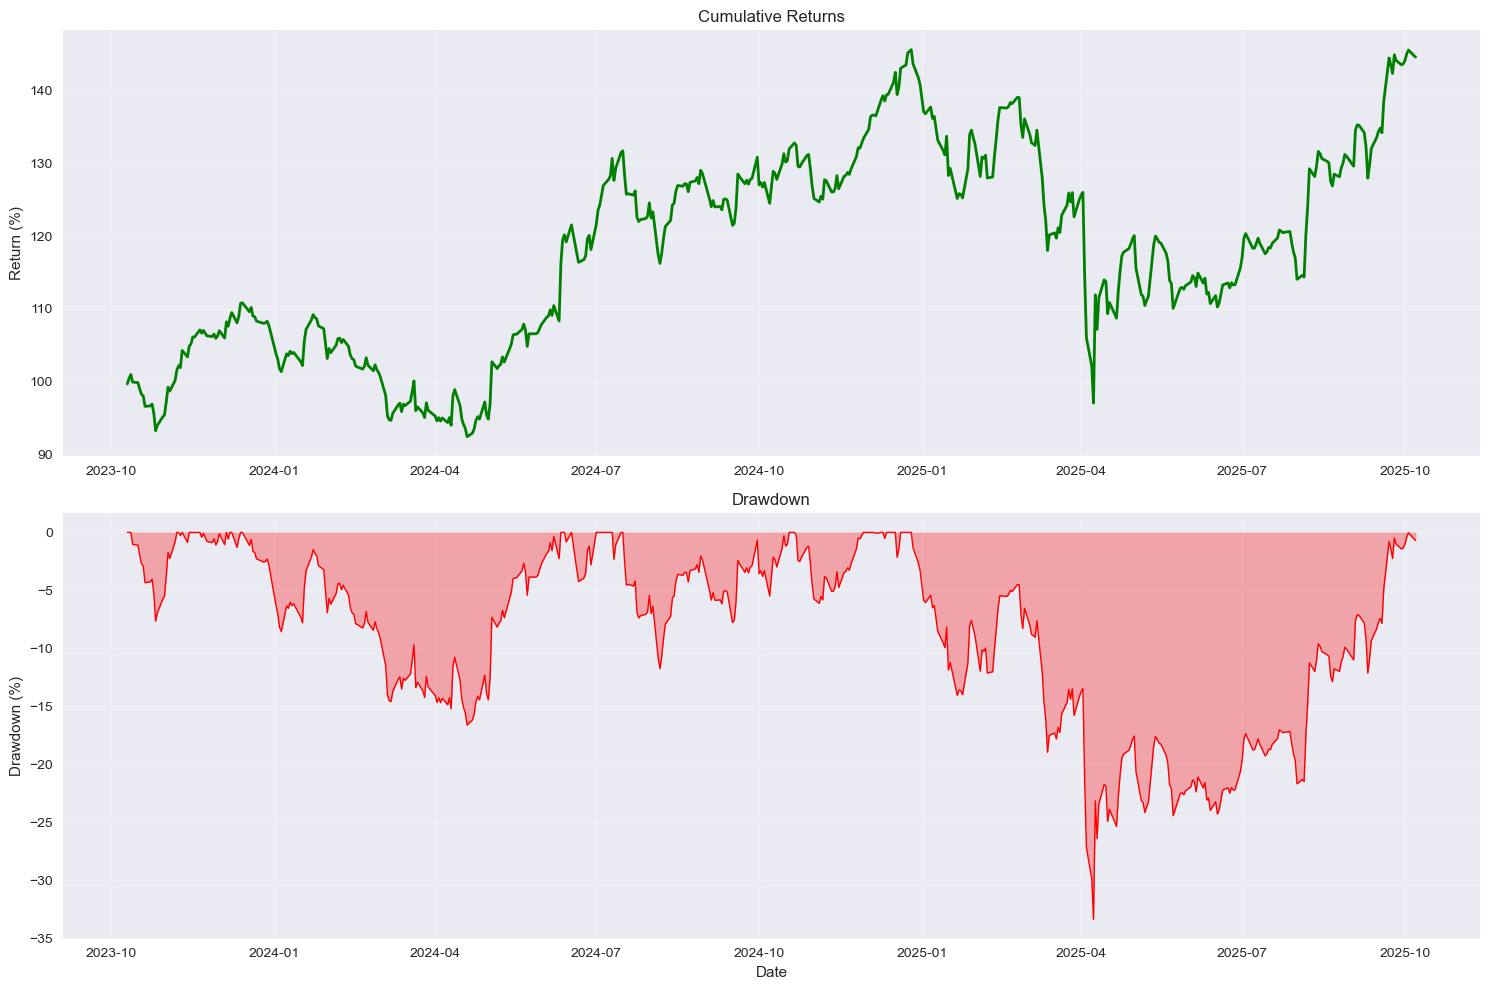


CONCLUSION AND INVESTMENT INSIGHTS

ANALYSIS SUMMARY FOR AAPL:
• Analysis Period: 2023-10-09 to 2025-10-07
• Total Return: 44.61%
• Risk Level: Medium
• Maximum Drawdown: -33.36%

CURRENT TECHNICAL SIGNALS:
• RSI: 74.5 - Overbought
• MACD: 6.95 - Bearish

RECOMMENDATIONS:
• STRONG SELL SIGNAL: Overbought with bearish MACD crossover

RISK MANAGEMENT STRATEGIES:
• Consider position sizing based on volatility
• Use stop-loss orders to limit downside risk
• Diversify across sectors to reduce concentration risk
• Monitor key technical levels for entry/exit points

ANALYSIS COMPLETED SUCCESSFULLY!


In [13]:
# ===== RISK ANALYSIS =====
print("\n=== RISK ANALYSIS ===")

# Calculate key metrics - FIXED: Ensure we get scalar values
total_return = float((stock_data['Close'].iloc[-1] - stock_data['Close'].iloc[0]) / stock_data['Close'].iloc[0] * 100)
avg_daily_return = float(stock_data['Daily_Return'].mean() * 100)
volatility = float(stock_data['Daily_Return'].std() * 100)
sharpe_ratio = float((avg_daily_return / volatility) * np.sqrt(252)) if volatility != 0 else 0

print(f"Total Return: {total_return:.2f}%")
print(f"Average Daily Return: {avg_daily_return:.3f}%")
print(f"Daily Volatility: {volatility:.3f}%")
print(f"Sharpe Ratio: {sharpe_ratio:.3f}")

# Drawdown analysis
stock_data['Cumulative_Return'] = (1 + stock_data['Daily_Return']).cumprod()
stock_data['Running_Max'] = stock_data['Cumulative_Return'].cummax()
stock_data['Drawdown'] = (stock_data['Cumulative_Return'] - stock_data['Running_Max']) / stock_data['Running_Max']

max_drawdown = float(stock_data['Drawdown'].min() * 100)
print(f"Maximum Drawdown: {max_drawdown:.2f}%")

# Plot cumulative returns and drawdown
plt.figure(figsize=(15, 10))

plt.subplot(2, 1, 1)
plt.plot(stock_data.index, stock_data['Cumulative_Return'] * 100, linewidth=2, color='green')
plt.title('Cumulative Returns')
plt.ylabel('Return (%)')
plt.grid(True, alpha=0.3)

plt.subplot(2, 1, 2)
plt.fill_between(stock_data.index, stock_data['Drawdown'] * 100, 0, color='red', alpha=0.3)
plt.plot(stock_data.index, stock_data['Drawdown'] * 100, linewidth=1, color='red')
plt.title('Drawdown')
plt.xlabel('Date')
plt.ylabel('Drawdown (%)')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ===== CONCLUSION AND INSIGHTS =====
print("\n" + "="*50)
print("CONCLUSION AND INVESTMENT INSIGHTS")
print("="*50)

print(f"\nANALYSIS SUMMARY FOR AAPL:")
print(f"• Analysis Period: {stock_data.index.min().strftime('%Y-%m-%d')} to {stock_data.index.max().strftime('%Y-%m-%d')}")
print(f"• Total Return: {total_return:.2f}%")
print(f"• Risk Level: {'High' if volatility > 2 else 'Medium' if volatility > 1 else 'Low'}")
print(f"• Maximum Drawdown: {max_drawdown:.2f}%")

# Current technical signals - FIXED: Ensure scalar values
current_rsi = float(stock_data['RSI'].iloc[-1])
current_macd = float(stock_data['MACD'].iloc[-1])
current_macd_signal = float(stock_data['MACD_Signal'].iloc[-1])

print(f"\nCURRENT TECHNICAL SIGNALS:")
print(f"• RSI: {current_rsi:.1f} - {'Overbought' if current_rsi > 70 else 'Oversold' if current_rsi < 30 else 'Neutral'}")
print(f"• MACD: {current_macd:.2f} - {'Bullish' if current_macd > current_macd_signal else 'Bearish'}")

print(f"\nRECOMMENDATIONS:")
if current_rsi < 30 and current_macd > current_macd_signal:
    print("• STRONG BUY SIGNAL: Oversold with bullish MACD crossover")
elif current_rsi > 70 and current_macd < current_macd_signal:
    print("• STRONG SELL SIGNAL: Overbought with bearish MACD crossover")
elif current_rsi < 40 and current_macd > current_macd_signal:
    print("• MODERATE BUY SIGNAL: Approaching oversold with bullish momentum")
elif current_rsi > 60 and current_macd < current_macd_signal:
    print("• MODERATE SELL SIGNAL: Approaching overbought with bearish momentum")
else:
    print("• HOLD: Mixed or neutral signals")

print(f"\nRISK MANAGEMENT STRATEGIES:")
print("• Consider position sizing based on volatility")
print("• Use stop-loss orders to limit downside risk")
print("• Diversify across sectors to reduce concentration risk")
print("• Monitor key technical levels for entry/exit points")

print("\n" + "="*50)
print("ANALYSIS COMPLETED SUCCESSFULLY!")
print("="*50)